<a href="https://colab.research.google.com/github/Nounsidev/PyTorch_Learning/blob/main/4_Classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [203]:
import sklearn

In [204]:

from sklearn.datasets import make_circles

nSamples = 1000

X, y = make_circles(nSamples, noise = 0.03, random_state = 42)

len(X), len(y)

(1000, 1000)

In [205]:
print(f"First 5 samples:\n {X[:5]}")
print(f"First 5 labels:\n {y[:5]}")

First 5 samples:
 [[ 0.75424625  0.23148074]
 [-0.75615888  0.15325888]
 [-0.81539193  0.17328203]
 [-0.39373073  0.69288277]
 [ 0.44220765 -0.89672343]]
First 5 labels:
 [1 1 1 1 0]


In [206]:
import pandas as pd

circles = pd.DataFrame({"X1": X[:, 0],
                        "X2": X[:, 1],
                        "label": y})
circles.head(10)

,X1,X2,label
0,0.754246,0.231481,1
1,-0.756159,0.153259,1
2,-0.815392,0.173282,1
3,-0.393731,0.692883,1
4,0.442208,-0.896723,0
5,-0.479646,0.676435,1
6,-0.013648,0.803349,1
7,0.771513,0.147760,1
8,-0.169322,-0.793456,1
9,-0.121486,1.021509,0


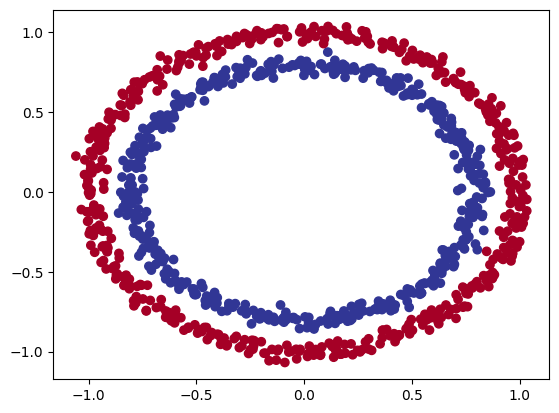

In [207]:
import matplotlib.pyplot as plt

plt.scatter(x = X[:, 0],
            y = X[:, 1],
            c = y,
            cmap = plt.cm.RdYlBu);

In [208]:
X.shape, y.shape

((1000, 2), (1000,))

In [209]:
#1. Turn Data into tensors
import torch
torch.__version__

'2.11.0+cu128'

In [210]:
X = torch.from_numpy(X).type(torch.float)
y = torch.from_numpy(y).type(torch.float)

X[:5]

tensor([[ 0.7542,  0.2315],
        [-0.7562,  0.1533],
        [-0.8154,  0.1733],
        [-0.3937,  0.6929],
        [ 0.4422, -0.8967]])

In [211]:
type(X)

torch.Tensor

In [212]:
#Split Data into training and test sets
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)

In [213]:
len(X_train), len(X_test), len(y_train), len(y_test)

(800, 200, 800, 200)

In [214]:
#2. BUILDING MODEL
import torch
from torch import nn
device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cuda'

In [215]:
class CircleModelV0(nn.Module):
  def __init__(self):
    super().__init__()

    #Create layer data capable of handling the shapes of our data
    self.layer_1 = nn.Linear(in_features=2, out_features = 5) #takes in 2 feature and upscale
    self.layer_2 = nn.Linear(in_features=5, out_features = 1) #output features

  #Forward Pass
  def forward(self, x):
    return self.layer_2(self.layer_1(x))


modelZero = CircleModelV0().to(device)
modelZero

CircleModelV0(
  (layer_1): Linear(in_features=2, out_features=5, bias=True)
  (layer_2): Linear(in_features=5, out_features=1, bias=True)
)

In [216]:
next(modelZero.parameters()).device

device(type='cuda', index=0)

In [217]:
modelZero = nn.Sequential(
    nn.Linear(in_features=2, out_features=5),
    nn.Linear(in_features=5, out_features=1)
).to(device)

modelZero

Sequential(
  (0): Linear(in_features=2, out_features=5, bias=True)
  (1): Linear(in_features=5, out_features=1, bias=True)
)

In [218]:
modelZero.state_dict()

OrderedDict([('0.weight',
              tensor([[ 0.1325, -0.3689],
                      [ 0.6710,  0.2995],
                      [-0.2543, -0.2357],
                      [-0.4333,  0.1204],
                      [-0.1524,  0.6214]], device='cuda:0')),
             ('0.bias',
              tensor([ 0.5307,  0.1275,  0.0325, -0.2212, -0.2845], device='cuda:0')),
             ('1.weight',
              tensor([[-0.2360, -0.0763,  0.2084,  0.1170,  0.3166]], device='cuda:0')),
             ('1.bias', tensor([-0.2684], device='cuda:0'))])

In [219]:
# MAKE PREDICTIONS

untrainedPreds = modelZero(X_test.to(device))
print(f"Length of predictions: {len(untrainedPreds)}, Shape: {untrainedPreds.shape}")
print(f"Length of test samples: {len(X_test)}, Shape: {X_test.shape}")
print(f"\nFirst 10 predictions:\n {untrainedPreds[:10]}")
print(f"\nFirst 10 test labels:\n {y_test[:10]}")

Length of predictions: 200, Shape: torch.Size([200, 1])
Length of test samples: 200, Shape: torch.Size([200, 2])

First 10 predictions:
 tensor([[-0.2704],
        [-0.2993],
        [-0.4190],
        [-0.2274],
        [-0.7750],
        [-0.7899],
        [-0.5891],
        [-0.7048],
        [-0.4037],
        [-0.3052]], device='cuda:0', grad_fn=<SliceBackward0>)

First 10 test labels:
 tensor([1., 0., 1., 0., 1., 1., 0., 0., 1., 0.])


In [220]:
# Loss funtion and optimizer

lossFunc = nn.BCEWithLogitsLoss()

optimizer = torch.optim.SGD(modelZero.parameters(), lr = 0.1)

In [221]:
#Calculate accuracy
def Accuracy_fn(y_true, y_pred):
  correct = torch.eq(y_true, y_pred).sum().item()
  acc = (correct / len(y_pred)) * 100
  return acc

In [222]:
# 3. TRAINING A MODEL
# 3.1 Going from raw logits -> pred prob -> pred labels

modelZero.eval()
with torch.inference_mode():
  y_logits = modelZero(X_test.to(device))[:5]
y_logits

tensor([[-0.2704],
        [-0.2993],
        [-0.4190],
        [-0.2274],
        [-0.7750]], device='cuda:0')

In [223]:
# Use sigmoid action func on our model logits to turn them into prediction probs

y_pred_probs = torch.sigmoid(y_logits)
y_pred_probs

tensor([[0.4328],
        [0.4257],
        [0.3968],
        [0.4434],
        [0.3154]], device='cuda:0')

In [224]:
y_preds = torch.round(y_pred_probs)

y_pred_labels = torch.round(torch.sigmoid(modelZero(X_test.to(device))[:5]))

print(torch.eq(y_pred_labels.squeeze(), y_preds.squeeze()))

y_preds.squeeze()

tensor([True, True, True, True, True], device='cuda:0')


tensor([0., 0., 0., 0., 0.], device='cuda:0')

In [225]:
### 3.2 BUILDING TRAIN AND TEST LOOP
torch.manual_seed(42)

#Set number of epoch
epochs = 1000

#Put data to target device
X_train, y_train = X_train.to(device), y_train.to(device)
X_test, y_test = X_test.to(device), y_test.to(device)

#Build training and evaluation loop
for epoch in range(epochs):
  modelZero.train()
  y_logits = modelZero(X_train).squeeze()
  y_pred = torch.round(torch.sigmoid(y_logits)) #turn logits -> pred probs -> pred labels

  loss = lossFunc(y_logits, y_train)
  acc = Accuracy_fn(y_true = y_train, y_pred = y_pred)

  optimizer.zero_grad()

  #Back propagation
  loss.backward()

  #Gradient Descent
  optimizer.step()

  modelZero.eval()
  with torch.inference_mode():
    # 1. FORWARD PASS
    test_logits = modelZero(X_test).squeeze()
    test_pred = torch.round(torch.sigmoid(test_logits))

    # 2. CALCULATE LOSS
    test_loss = lossFunc(test_logits, y_test)
    test_acc = Accuracy_fn(y_true = y_test, y_pred = test_pred)

    if epoch % 10 == 0:
      print(f"Epoch: {epoch} | Loss: {loss:.5f} | Accuracy: {acc:.2f}% | Test Loss: {test_loss:.5f} | Test Accuracy: {test_acc:.2f}%")

Epoch: 0 | Loss: 0.73059 | Accuracy: 50.00% | Test Loss: 0.72809 | Test Accuracy: 50.00%
Epoch: 10 | Loss: 0.71003 | Accuracy: 50.00% | Test Loss: 0.70968 | Test Accuracy: 50.00%
Epoch: 20 | Loss: 0.70111 | Accuracy: 49.88% | Test Loss: 0.70162 | Test Accuracy: 49.50%
Epoch: 30 | Loss: 0.69708 | Accuracy: 41.12% | Test Loss: 0.69796 | Test Accuracy: 39.50%
Epoch: 40 | Loss: 0.69520 | Accuracy: 47.25% | Test Loss: 0.69625 | Test Accuracy: 43.00%
Epoch: 50 | Loss: 0.69430 | Accuracy: 48.88% | Test Loss: 0.69544 | Test Accuracy: 45.00%
Epoch: 60 | Loss: 0.69384 | Accuracy: 49.00% | Test Loss: 0.69506 | Test Accuracy: 48.00%
Epoch: 70 | Loss: 0.69360 | Accuracy: 48.62% | Test Loss: 0.69487 | Test Accuracy: 51.00%
Epoch: 80 | Loss: 0.69346 | Accuracy: 49.00% | Test Loss: 0.69478 | Test Accuracy: 52.00%
Epoch: 90 | Loss: 0.69337 | Accuracy: 49.62% | Test Loss: 0.69474 | Test Accuracy: 51.50%
Epoch: 100 | Loss: 0.69330 | Accuracy: 49.88% | Test Loss: 0.69472 | Test Accuracy: 52.50%
Epoch: 110

In [226]:
# 4. PREDICTION
import requests
from pathlib import Path

# Download helper functions
if Path("helper_functions.py").is_file():
  print("Helper functions already downloaded")
else:
  print("Downloading helper functions...")
  request = requests.get("https://raw.githubusercontent.com/mrdbourke/pytorch-deep-learning/refs/heads/main/helper_functions.py")

  #Write Binary
  with open("helper_functions.py", "wb") as f:
    f.write(request.content)

from helper_functions import plot_predictions, plot_decision_boundary


Helper functions already downloaded


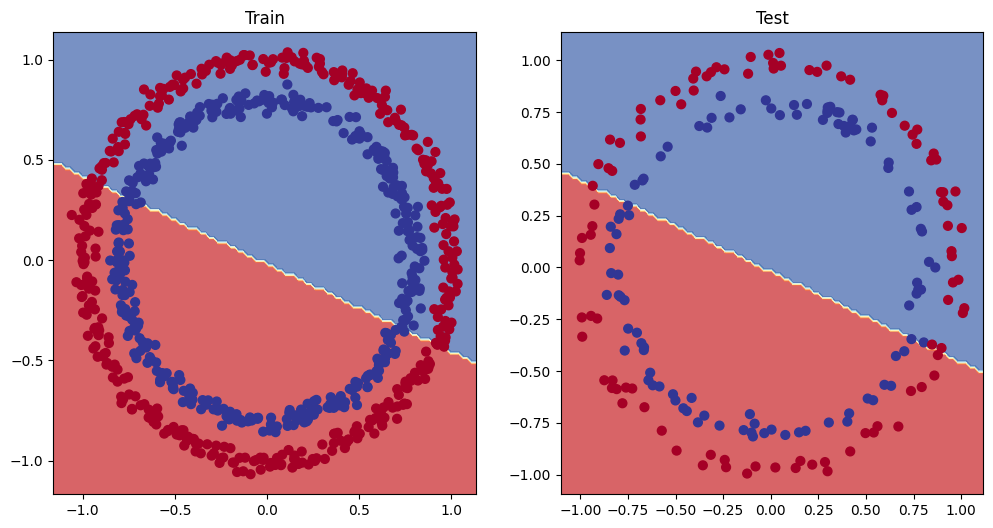

In [227]:
plt.figure(figsize=(12, 6))

#TRAIN PLOT
plt.subplot(1, 2, 1)
plt.title("Train")
plot_decision_boundary(modelZero, X_train, y_train)

#TEST PLOT
plt.subplot(1, 2, 2)
plt.title("Test")
plot_decision_boundary(modelZero, X_test, y_test)

In [228]:
# 5. IMPROVING MODEL
# 5.1 BUILD MODEL
class CircleModelV1(nn.Module):
  def __init__(self):
    super().__init__()
    self.layer_1 = nn.Linear(in_features = 2, out_features = 10)
    self.layer_2 = nn.Linear(in_features = 10, out_features = 10)
    self.layer_3 = nn.Linear(in_features = 10, out_features = 1)

  def forward(self, x):
    return self.layer_3(self.layer_2(self.layer_1(x)))

modelV1 = CircleModelV1().to(device)
modelV1


CircleModelV1(
  (layer_1): Linear(in_features=2, out_features=10, bias=True)
  (layer_2): Linear(in_features=10, out_features=10, bias=True)
  (layer_3): Linear(in_features=10, out_features=1, bias=True)
)

In [229]:
#5.2 LOSS AND OPTIMIZER

lossFunc = nn.BCEWithLogitsLoss()

optimizer = torch.optim.SGD(modelZero.parameters(), lr = 0.01)

In [230]:
torch.manual_seed(42)

epochs = 1000

X_train, y_train = X_train.to(device), y_train.to(device)
X_test, y_test = X_test.to(device), y_test.to(device)

for epoch in range(epochs):
  modelV1.train()

  #Forward Pass
  y_logits = modelV1(X_train).squeeze()
  y_pred = torch.round(torch.sigmoid(y_logits))

  #Calculate Loss
  loss = lossFunc(y_logits, y_train)
  acc = Accuracy_fn(y_true = y_train, y_pred = y_pred)

  optimizer.zero_grad()

  loss.backward()

  optimizer.step()

  # TESTING
  modelV1.eval()
  with torch.inference_mode():
    test_logits = modelV1(X_test).squeeze()
    test_pred = torch.round(torch.sigmoid(test_logits))

    test_loss = lossFunc(test_logits, y_test)
    test_acc = Accuracy_fn(y_true = y_test, y_pred = test_pred)

    if epoch % 100 == 0:
      print(f"Epoch: {epoch} | Loss: {loss:.5f} | Accuracy: {acc:.2f}% | Test Loss: {test_loss:.5f} | Test Accuracy: {test_acc:.2f}%")

Epoch: 0 | Loss: 0.69396 | Accuracy: 50.88% | Test Loss: 0.69261 | Test Accuracy: 51.00%
Epoch: 100 | Loss: 0.69396 | Accuracy: 50.88% | Test Loss: 0.69261 | Test Accuracy: 51.00%
Epoch: 200 | Loss: 0.69396 | Accuracy: 50.88% | Test Loss: 0.69261 | Test Accuracy: 51.00%
Epoch: 300 | Loss: 0.69396 | Accuracy: 50.88% | Test Loss: 0.69261 | Test Accuracy: 51.00%
Epoch: 400 | Loss: 0.69396 | Accuracy: 50.88% | Test Loss: 0.69261 | Test Accuracy: 51.00%
Epoch: 500 | Loss: 0.69396 | Accuracy: 50.88% | Test Loss: 0.69261 | Test Accuracy: 51.00%
Epoch: 600 | Loss: 0.69396 | Accuracy: 50.88% | Test Loss: 0.69261 | Test Accuracy: 51.00%
Epoch: 700 | Loss: 0.69396 | Accuracy: 50.88% | Test Loss: 0.69261 | Test Accuracy: 51.00%
Epoch: 800 | Loss: 0.69396 | Accuracy: 50.88% | Test Loss: 0.69261 | Test Accuracy: 51.00%
Epoch: 900 | Loss: 0.69396 | Accuracy: 50.88% | Test Loss: 0.69261 | Test Accuracy: 51.00%


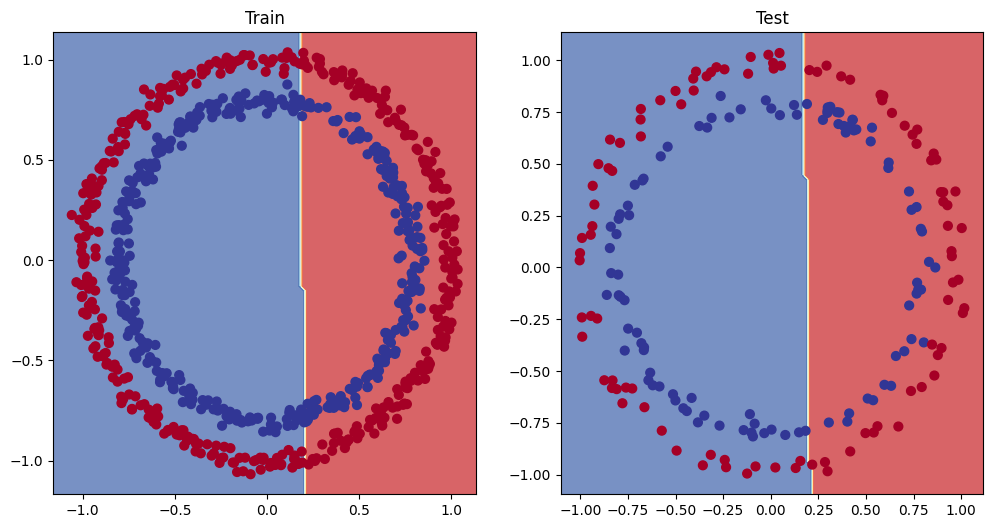

In [231]:
plt.figure(figsize=(12, 6))

#TRAIN PLOT
plt.subplot(1, 2, 1)
plt.title("Train")
plot_decision_boundary(modelV1, X_train, y_train)

#TEST PLOT
plt.subplot(1, 2, 2)
plt.title("Test")
plot_decision_boundary(modelV1, X_test, y_test)

In [232]:
# 5.2 TROUBLE SHOOTING WITH SMALLER DATASET

weight = 0.7
bias = 0.3

start = 0
end = 1
step = 0.01

#Create Data
X_regression = torch.arange(start, end, step).unsqueeze(dim = 1)
y_regression = weight * X_regression + bias

print(len(X_regression))
X_regression[:5], y_regression[:5]



100


(tensor([[0.0000],
         [0.0100],
         [0.0200],
         [0.0300],
         [0.0400]]),
 tensor([[0.3000],
         [0.3070],
         [0.3140],
         [0.3210],
         [0.3280]]))

In [233]:
train_split = int(0.8 * len(X_regression))
X_train_regression, y_train_regression = X_regression[:train_split], y_regression[:train_split]
X_test_regression, y_test_regression = X_regression[train_split:], y_regression[train_split:]

len(X_train_regression), len(y_train_regression), len(X_test_regression), len(y_test_regression)

(80, 80, 20, 20)

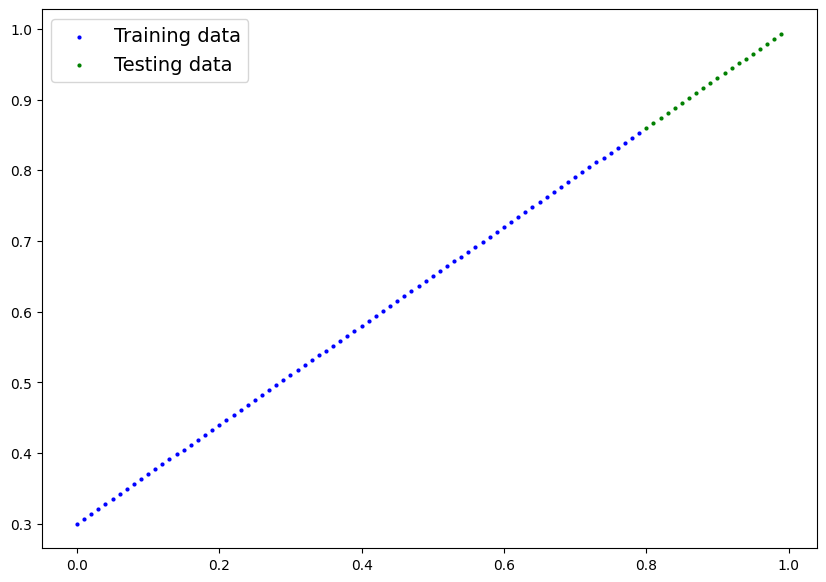

In [234]:
plot_predictions(X_train_regression, y_train_regression, X_test_regression, y_test_regression)

In [235]:
# 5.3 ADJUSTING MODEV1 to fit a straight line

modelV2 = nn.Sequential(
    nn.Linear(in_features = 1, out_features = 10),
    nn.Linear(in_features = 10, out_features = 10),
    nn.Linear(in_features = 10, out_features = 1)
).to(device)

modelV2

Sequential(
  (0): Linear(in_features=1, out_features=10, bias=True)
  (1): Linear(in_features=10, out_features=10, bias=True)
  (2): Linear(in_features=10, out_features=1, bias=True)
)

In [236]:
loss_fn = nn.L1Loss()
optimizer = torch.optim.SGD(modelV2.parameters(), lr = 0.01)

In [237]:
torch.manual_seed(38)

epochs = 1000

X_train_regression, y_train_regression = X_train_regression.to(device), y_train_regression.to(device)
X_test_regression, y_test_regression = X_test_regression.to(device), y_test_regression.to(device)

for epoch in range(epochs):
  modelV2.train()

  y_pred = modelV2(X_train_regression)
  loss = loss_fn(y_pred, y_train_regression)

  optimizer.zero_grad()

  loss.backward()

  optimizer.step()

  modelV2.eval()
  with torch.inference_mode():
    test_pred = modelV2(X_test_regression)
    test_loss = loss_fn(test_pred, y_test_regression)

  if epoch % 100 == 0:
    print(f"Epoch: {epoch} | Loss: {loss:.5f} | Test Loss: {test_loss:.5f}")

Epoch: 0 | Loss: 0.75986 | Test Loss: 0.91103
Epoch: 100 | Loss: 0.02858 | Test Loss: 0.00081
Epoch: 200 | Loss: 0.02533 | Test Loss: 0.00209
Epoch: 300 | Loss: 0.02137 | Test Loss: 0.00305
Epoch: 400 | Loss: 0.01964 | Test Loss: 0.00341
Epoch: 500 | Loss: 0.01940 | Test Loss: 0.00387
Epoch: 600 | Loss: 0.01903 | Test Loss: 0.00379
Epoch: 700 | Loss: 0.01878 | Test Loss: 0.00381
Epoch: 800 | Loss: 0.01840 | Test Loss: 0.00329
Epoch: 900 | Loss: 0.01798 | Test Loss: 0.00360


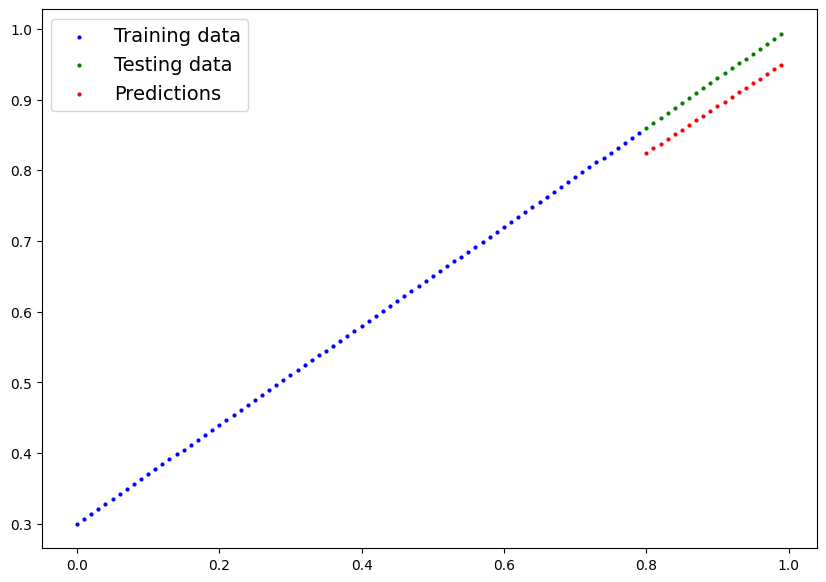

In [238]:
modelV2.eval()

with torch.inference_mode():
  y_preds = modelV2(X_test_regression)

plot_predictions(X_train_regression.cpu(), y_train_regression.cpu(), X_test_regression.cpu(), y_test_regression.cpu(), y_preds.cpu())

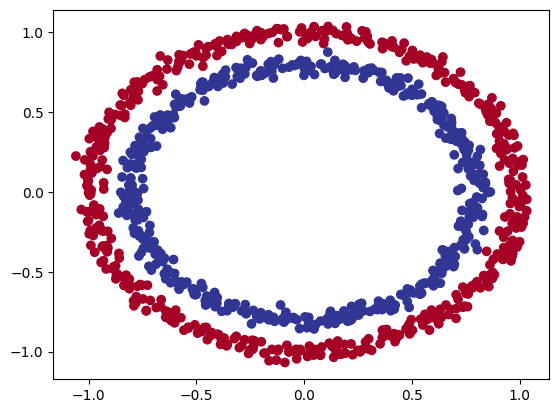

In [239]:
# 6. NON LINEARITY

import matplotlib.pyplot as plt
from sklearn.datasets import make_circles
n_samples = 1000

x, y = make_circles(n_samples, noise = 0.03, random_state = 42)

plt.scatter(X[:, 0], X[:, 1], c = y, cmap = plt.cm.RdYlBu);

In [240]:
import torch
from sklearn.model_selection import train_test_split



X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)

len(X_train), len(X_test), len(y_train), len(y_test)

(800, 200, 800, 200)

In [241]:
# 6.2 BUILDING A MODEL WITH NON LINEARITY
from torch import nn

class CircleModelV2(nn.Module):
  def __init__(self):
    super().__init__()
    self.layer_1 = nn.Linear(in_features=2, out_features=10)
    self.layer_2 = nn.Linear(in_features=10, out_features=10)
    self.layer_3 = nn.Linear(in_features=10, out_features=1)
    self.relu = nn.ReLU()

  def forward(self, x):
    #Where should we put our non-linear activation functions?
    return self.layer_3(self.relu(self.layer_2(self.relu(self.layer_1(x)))))

modelV3 = CircleModelV2().to(device)
modelV3

CircleModelV2(
  (layer_1): Linear(in_features=2, out_features=10, bias=True)
  (layer_2): Linear(in_features=10, out_features=10, bias=True)
  (layer_3): Linear(in_features=10, out_features=1, bias=True)
  (relu): ReLU()
)

In [242]:
# LOSS AND OPTIMIZER
loss_fn = nn.BCEWithLogitsLoss()

optimizer = torch.optim.SGD(modelV3.parameters(), lr = 0.1)

In [243]:
len(X_test), len(y_test)

(200, 200)

In [244]:
#. TRAINING AND TEST LOOP
torch.manual_seed(42)

epochs = 1000

# Wrap with torch.from_numpy or torch.tensor before moving to device
X_train, y_train = torch.tensor(X_train).to(device), torch.tensor(y_train).float().to(device)
X_test, y_test = torch.tensor(X_test).to(device), torch.tensor(y_test).float().to(device)

for epoch in range(epochs):
  modelV3.train()

  #Forward Pass
  y_logits = modelV3(X_train).squeeze()
  y_pred = torch.round(torch.sigmoid(y_logits))

  #Calculate Loss
  loss = loss_fn(y_logits, y_train)
  acc = Accuracy_fn(y_true = y_train, y_pred = y_pred)

  optimizer.zero_grad()

  loss.backward()

  optimizer.step()

  # TESTING
  modelV3.eval()
  with torch.inference_mode():
    test_logits = modelV3(X_test).squeeze()
    test_pred = torch.round(torch.sigmoid(test_logits))

    test_loss = loss_fn(test_logits, y_test)
    test_acc = Accuracy_fn(y_true = y_test, y_pred = test_pred)

    if epoch % 100 == 0:
      print(f"Epoch: {epoch} | Loss: {loss:.5f} | Accuracy: {acc:.2f}% | Test Loss: {test_loss:.5f} | Test Accuracy: {test_acc:.2f}%")


/tmp/ipykernel_3573/2171606689.py:7: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  X_train, y_train = torch.tensor(X_train).to(device), torch.tensor(y_train).float().to(device)
/tmp/ipykernel_3573/2171606689.py:8: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  X_test, y_test = torch.tensor(X_test).to(device), torch.tensor(y_test).float().to(device)


Epoch: 0 | Loss: 0.69367 | Accuracy: 45.50% | Test Loss: 0.69445 | Test Accuracy: 43.00%
Epoch: 100 | Loss: 0.69054 | Accuracy: 52.38% | Test Loss: 0.69252 | Test Accuracy: 47.50%
Epoch: 200 | Loss: 0.68792 | Accuracy: 54.62% | Test Loss: 0.69105 | Test Accuracy: 48.50%
Epoch: 300 | Loss: 0.68440 | Accuracy: 57.38% | Test Loss: 0.68910 | Test Accuracy: 51.00%
Epoch: 400 | Loss: 0.67954 | Accuracy: 59.38% | Test Loss: 0.68608 | Test Accuracy: 56.00%
Epoch: 500 | Loss: 0.67292 | Accuracy: 61.25% | Test Loss: 0.68141 | Test Accuracy: 56.50%
Epoch: 600 | Loss: 0.66316 | Accuracy: 63.62% | Test Loss: 0.67334 | Test Accuracy: 59.00%
Epoch: 700 | Loss: 0.64749 | Accuracy: 67.50% | Test Loss: 0.66024 | Test Accuracy: 62.00%
Epoch: 800 | Loss: 0.61835 | Accuracy: 74.62% | Test Loss: 0.63231 | Test Accuracy: 71.50%
Epoch: 900 | Loss: 0.56841 | Accuracy: 84.38% | Test Loss: 0.58313 | Test Accuracy: 81.00%


In [245]:
#Make Predictions
modelV3.eval()

with torch.inference_mode():
  y_preds = torch.round(torch.sigmoid(modelV3(X_test))).squeeze()

y_preds[:10], y_test[:10]


(tensor([1., 0., 1., 0., 1., 1., 1., 0., 1., 0.], device='cuda:0'),
 tensor([1., 0., 1., 0., 1., 1., 0., 0., 1., 0.], device='cuda:0'))

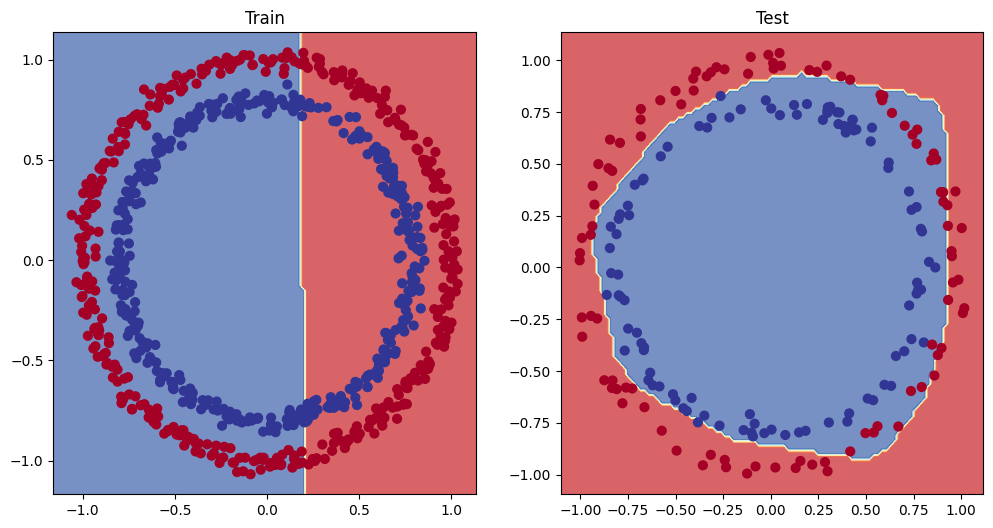

In [246]:
plt.figure(figsize=(12, 6))

#TRAIN PLOT
plt.subplot(1, 2, 1)
plt.title("Train")
plot_decision_boundary(modelV1, X_train, y_train)

#TEST PLOT
plt.subplot(1, 2, 2)
plt.title("Test")
plot_decision_boundary(modelV3, X_test, y_test)

In [247]:
# 7. REPLICATING NON LINEAR ACTIVATION FUNCTION

A = torch.arange(-10, 10, 1, dtype = torch.float32)
A.dtype

torch.float32

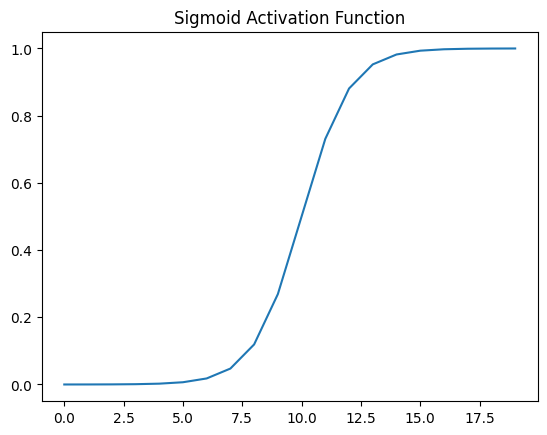

In [248]:
plt.plot(torch.sigmoid(A))
plt.title("Sigmoid Activation Function")
plt.show()

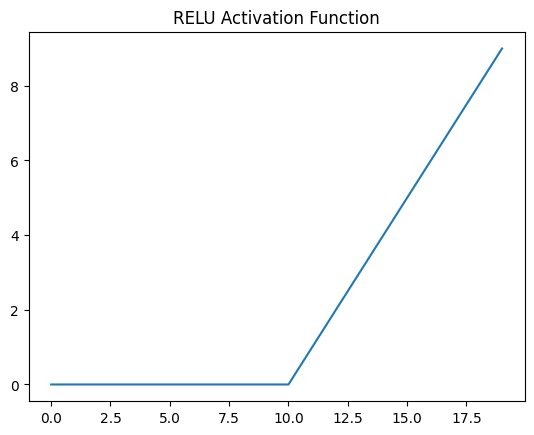

In [249]:
def relu(x: torch.Tensor) -> torch.Tensor:
  return torch.maximum(torch.tensor(0), x)

relu(A)

plt.plot(torch.relu(A))
plt.title("RELU Activation Function")
plt.show()

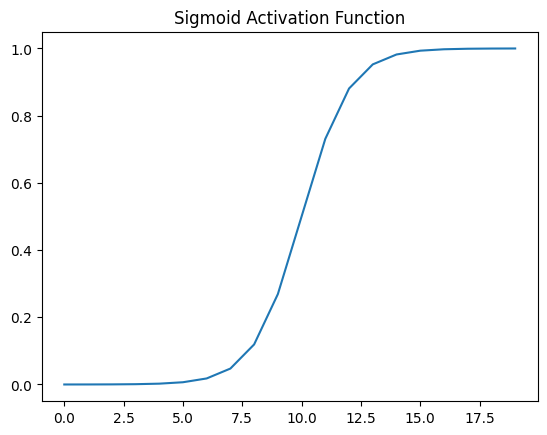

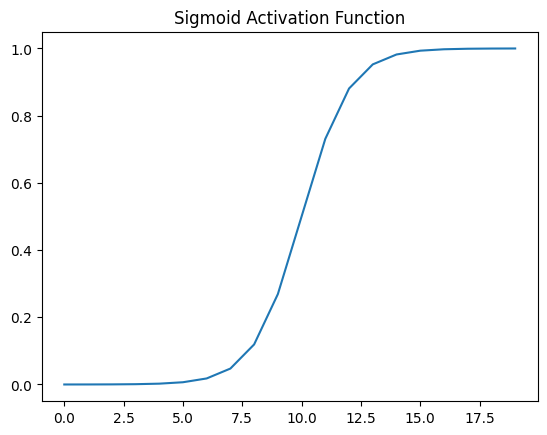

In [250]:
def sigmoid(x):
  return 1 / (1 + torch.exp(-x))

plt.plot(torch.sigmoid(A))
plt.title("Sigmoid Activation Function")
plt.show()

plt.plot(sigmoid(A))
plt.title("Sigmoid Activation Function")
plt.show()

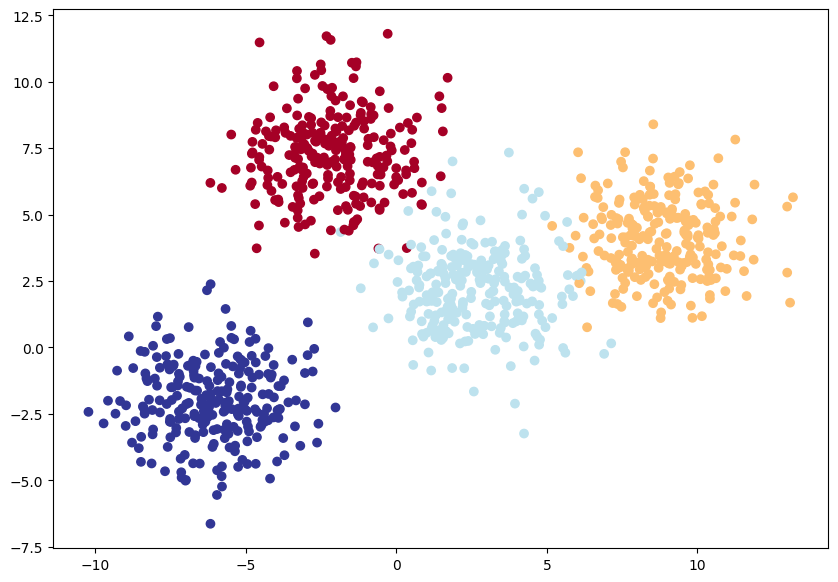

In [251]:
#8 Putting it all together with a multi class classification problem

#8.1 Creating a toy multi-class dataset

import torch
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from sklearn.model_selection import train_test_split

NUM_CLASSES = 4
NUM_FEATURES = 2
RANDOM_SEED = 38

#Create multiple classes data
X_blob, y_blob = make_blobs(n_samples = 1000, n_features = NUM_FEATURES, centers = NUM_CLASSES, cluster_std = 1.5, random_state = RANDOM_SEED)

#Create train and test split
X_blob = torch.from_numpy(X_blob).type(torch.float)
y_blob = torch.from_numpy(y_blob).type(torch.LongTensor)


X_blob_train, X_blob_test, y_blob_train, y_blob_test = train_test_split(X_blob, y_blob, test_size = 0.2, random_state = RANDOM_SEED)


# Plot Data
plt.figure(figsize = (10, 7))
plt.scatter(X_blob[:, 0], X_blob[:, 1], c = y_blob, cmap = plt.cm.RdYlBu)


In [252]:
#Create device agnostic code
import torch
from torch import nn
device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cuda'

In [265]:
class BlobModel(nn.Module):
  def __init__(self, input_features, output_features, hidden_units = 8):
    super().__init__()
    self.linear_layer_stack = nn.Sequential(
        nn.Linear(in_features=input_features, out_features=hidden_units),
        nn.ReLU(),
        nn.Linear(in_features=hidden_units, out_features=hidden_units),
        nn.ReLU(),
        nn.Linear(in_features=hidden_units, out_features=output_features)
    )

  def forward(self, x):
    return self.linear_layer_stack(x)


modelV4 = BlobModel(input_features = 2, output_features = 4, hidden_units=8).to(device)
modelV4.to(device)
modelV4


BlobModel(
  (linear_layer_stack): Sequential(
    (0): Linear(in_features=2, out_features=8, bias=True)
    (1): ReLU()
    (2): Linear(in_features=8, out_features=8, bias=True)
    (3): ReLU()
    (4): Linear(in_features=8, out_features=4, bias=True)
  )
)

In [279]:
# Create a loss func and an optimizer

loss_fn = nn.CrossEntropyLoss()

optimizer = torch.optim.SGD(params = modelV4.parameters(), lr = 0.0001)

In [267]:
print(next(modelV4.parameters()).device)
print(X_blob_test.device)
print(y_logits.device)

cuda:0
cuda:0
cuda:0


In [256]:
modelV4.eval()
with torch.inference_mode():
  y_logits = modelV4(X_blob_test.to(device))

y_logits[:10]

tensor([[ 0.0290, -0.6704, -0.4022, -0.1359],
        [-0.1187, -0.9723, -0.6908, -0.1958],
        [-0.1457, -1.0374, -0.7398, -0.2000],
        [-0.0729, -0.8712, -0.5845, -0.1656],
        [-1.3697, -0.9582, -2.5250, -1.7888],
        [-0.0031, -0.7186, -0.4195, -0.1164],
        [ 0.1836, -0.3426,  0.0334,  0.0375],
        [-0.5766, -0.6091, -1.1762, -0.8193],
        [-0.3714, -0.5881, -0.9269, -0.6911],
        [-0.1288, -0.9840, -0.7406, -0.2287]], device='cuda:0')

In [268]:
#Convert model's logit outputs to pred probs

y_pred_probs = torch.softmax(y_logits, dim = 1)
print(y_pred_probs[:10])
print(y_logits[:10])


tensor([[0.3930, 0.1443, 0.2697, 0.1930],
        [0.5975, 0.0690, 0.1342, 0.1992],
        [0.6303, 0.0599, 0.1066, 0.2032],
        [0.5575, 0.0793, 0.1565, 0.2067],
        [0.0153, 0.7958, 0.1830, 0.0059],
        [0.4975, 0.0957, 0.1883, 0.2185],
        [0.3577, 0.1344, 0.2343, 0.2737],
        [0.0913, 0.5338, 0.3159, 0.0590],
        [0.1459, 0.4057, 0.3648, 0.0837],
        [0.5930, 0.0739, 0.1525, 0.1806]], device='cuda:0')
tensor([[-8.6994e-02, -1.0890e+00, -4.6341e-01, -7.9780e-01],
        [ 2.8697e-01, -1.8712e+00, -1.2066e+00, -8.1137e-01],
        [ 3.3451e-01, -2.0192e+00, -1.4422e+00, -7.9749e-01],
        [ 2.7054e-01, -1.6792e+00, -1.0001e+00, -7.2169e-01],
        [-3.4396e+00,  5.1325e-01, -9.5684e-01, -4.3898e+00],
        [ 2.5763e-01, -1.3903e+00, -7.1423e-01, -5.6546e-01],
        [ 2.7143e-01, -7.0750e-01, -1.5160e-01,  3.7384e-03],
        [-1.5669e+00,  1.9935e-01, -3.2542e-01, -2.0028e+00],
        [-1.1893e+00, -1.6648e-01, -2.7278e-01, -1.7454e+00],
    

In [258]:
y_preds = torch.argmax(y_pred_probs, dim = 1)
y_preds[:10]

tensor([0, 0, 0, 0, 1, 0, 0, 0, 0, 0], device='cuda:0')

In [280]:
# 8.5 Training and testing loop for a multi-class PyTorch model
torch.manual_seed(38)

epochs = 10000

X_blob_train, y_blob_train = X_blob_train.to(device), y_blob_train.to(device)
X_blob_test, y_blob_test = X_blob_test.to(device), y_blob_test.to(device)

for epoch in range(epochs):
  modelV4.train()

  y_logits = modelV4(X_blob_train).squeeze()
  y_pred = torch.softmax(y_logits, dim = 1).argmax(dim=1)

  loss = loss_fn(y_logits, y_blob_train)
  acc = Accuracy_fn(y_true = y_blob_train, y_pred = y_pred)

  optimizer.zero_grad()
  loss.backward()
  optimizer.step()

  #Testing
  modelV4.eval()
  with torch.inference_mode():
    test_logits = modelV4(X_blob_test).squeeze()
    test_pred = torch.softmax(test_logits, dim = 1).argmax(dim = 1)

    test_loss = loss_fn(test_logits, y_blob_test)
    test_acc = Accuracy_fn(y_true = y_blob_test, y_pred = test_pred)

    if epoch % 1000 == 0:
      print(f"Epoch: {epoch} | Loss: {loss:.5f} | Accuracy: {acc:.2f}% | Test Loss: {test_loss:.5f} | Test Accuracy: {test_acc:.2f}%")

Epoch: 0 | Loss: 0.35651 | Accuracy: 96.25% | Test Loss: 0.36500 | Test Accuracy: 96.00%
Epoch: 1000 | Loss: 0.35436 | Accuracy: 96.25% | Test Loss: 0.36297 | Test Accuracy: 96.00%
Epoch: 2000 | Loss: 0.35223 | Accuracy: 96.25% | Test Loss: 0.36096 | Test Accuracy: 95.50%
Epoch: 3000 | Loss: 0.35011 | Accuracy: 96.25% | Test Loss: 0.35897 | Test Accuracy: 95.50%
Epoch: 4000 | Loss: 0.34801 | Accuracy: 96.25% | Test Loss: 0.35699 | Test Accuracy: 95.50%
Epoch: 5000 | Loss: 0.34593 | Accuracy: 96.25% | Test Loss: 0.35503 | Test Accuracy: 95.50%
Epoch: 6000 | Loss: 0.34387 | Accuracy: 96.25% | Test Loss: 0.35310 | Test Accuracy: 95.50%
Epoch: 7000 | Loss: 0.34182 | Accuracy: 96.25% | Test Loss: 0.35118 | Test Accuracy: 95.50%
Epoch: 8000 | Loss: 0.33979 | Accuracy: 96.38% | Test Loss: 0.34928 | Test Accuracy: 95.50%
Epoch: 9000 | Loss: 0.33777 | Accuracy: 96.38% | Test Loss: 0.34740 | Test Accuracy: 95.50%


In [284]:
#Make Prediction
modelV4.eval()

with torch.inference_mode():
  y_logits = modelV4(X_blob_test)

y_pred_probs = torch.softmax(y_logits, dim = 1)
y_preds = torch.argmax(y_pred_probs, dim = 1)

y_preds[:10], y_pred_probs[:10]



RuntimeError: Expected all tensors to be on the same device, but got mat1 is on cuda:0, different from other tensors on cpu (when checking argument in method wrapper_CUDA_addmm)

In [285]:
# Pred Probs -> pred labels
y_preds = torch.argmax(y_pred_probs, dim = 1)
y_preds[:10]


tensor([0, 0, 0, 0, 1, 0, 0, 1, 1, 0], device='cuda:0')

In [286]:
y_blob_test[:10]

tensor([2, 0, 0, 0, 1, 0, 3, 2, 2, 0], device='cuda:0')

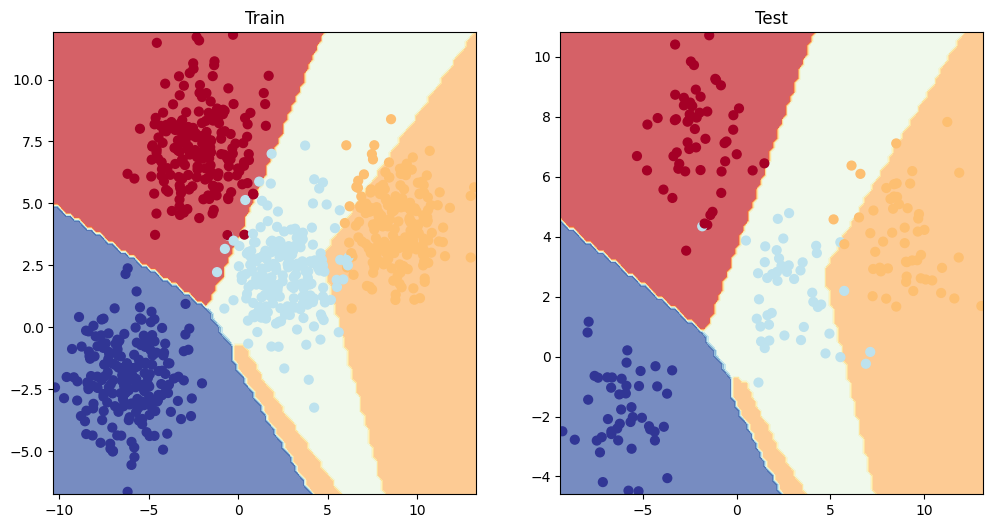

In [287]:
plt.figure(figsize=(12, 6))

#TRAIN PLOT
plt.subplot(1, 2, 1)
plt.title("Train")
plot_decision_boundary(modelV4, X_blob_train, y_blob_train)

#TEST PLOT
plt.subplot(1, 2, 2)
plt.title("Test")
plot_decision_boundary(modelV4, X_blob_test, y_blob_test)

In [288]:
#9. FEW MORE CLASSIFICATION METRIC

!pip install torchmetrics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 24.0 MB/s eta 0:00:00


In [292]:
from torchmetrics import Accuracy

#setup metric
torchmetric_accuracy = Accuracy(task="multiclass", num_classes=4).to(device)

torchmetric_accuracy(y_preds, y_blob_test)

tensor(0.6500, device='cuda:0')